# Adding Reinforcement Learning to the Comparison

The previous notebook compared PCR, OLS, and Post-Lasso (double selection) as three ways of turning a large, correlated predictor set into a return forecast. This notebook adds a fundamentally different paradigm — **reinforcement learning** — and repeats the exercise on the same simulated market, asking the same question: whose resulting trading strategy earns a cumulative-return trace that holds up out of sample, over the next 250 trading days?

## 1. What Is Reinforcement Learning, and What Is It Aiming For?

Every model in the previous notebook was **supervised learning**: each has a labeled target $y_t$ (the fund's realized return) and is fit by directly minimizing prediction error against that label — OLS and Post-Lasso via closed-form/least-squares, PCR the same after a dimensionality reduction step.

**Reinforcement learning (RL)** solves a different kind of problem. An *agent* interacts with an *environment* over a sequence of steps: at each step it observes a *state* $s_t$, chooses an *action* $a_t$ according to a *policy* $\pi$, and receives a scalar *reward* $r_t$ — but it is never told what the "correct" action was. The aim is to learn a policy that **maximizes cumulative reward**, discovered through trial and error rather than from labeled examples. Two features distinguish it from supervised learning:

- **No direct error signal.** The agent only knows how good its own chosen action turned out to be, not what the best action would have been. It must explore — trying actions with some randomness — to find out.
- **Credit assignment over a sequence.** Actions can affect future rewards, not just the immediate one, so the learning signal has to be attributed correctly across time (in the general case; see the framing note below).

**Applying this to trading.** Here, the state is yesterday's returns across the 400-asset universe, the action is a **position size** in $[-1, 1]$ (how long or short to be in the target fund), and the reward is the realized P&L, $r_t = a_t \cdot y_t$. Because the agent's trades don't move this (simulated) market, choosing $a_t$ today doesn't change tomorrow's state — so this reduces to a **contextual bandit**: a one-step RL problem, without the multi-step credit-assignment complexity of a full Markov Decision Process. That's a standard, honest simplification for this kind of signal-driven trading model, and it's still genuinely RL: the agent is never given $y_t$ as a training label, only the reward earned by the action it actually took.

**The learning algorithm — policy gradient (REINFORCE).** A linear-Gaussian policy is used: mean position $\mu_t = \tanh(w \cdot s_t)$, with Gaussian exploration noise added during training, $a_t \sim \mathcal{N}(\mu_t, \sigma^2)$ (clipped to $[-1,1]$). The weight vector $w$ is updated in the direction that makes profitable actions more likely:

$$w \;\leftarrow\; w + \eta\,(r_t - b)\,\nabla_w \log \pi(a_t \mid s_t)$$

where $b$ is a running-average reward baseline (reduces variance without introducing bias) and $\eta$ is the learning rate. Exploration noise $\sigma$ is annealed from wide to narrow over training, so the agent explores early and exploits what it's learned later.

## 2. Same Market, Same Target

The identical simulated universe from the previous notebook is reused, so the comparison is apples-to-apples: 400 assets across 20 sectors, 8 years of daily data, and a fund whose return is driven by 6 true "leader" assets (population $R^2 \approx 15\%$) plus dominant noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(11)

n_sectors, sector_size = 20, 20
N = n_sectors * sector_size
sectors = np.repeat([f"S{i+1}" for i in range(n_sectors)], sector_size)
corr = np.full((N, N), 0.08)
for s in range(n_sectors):
    idx = np.where(sectors == f"S{s+1}")[0]
    corr[np.ix_(idx, idx)] = 0.45
np.fill_diagonal(corr, 1.0)

vols = rng.uniform(0.10, 0.30, N)
cov_annual = np.outer(vols, vols) * corr
mu_annual = rng.uniform(0.02, 0.10, N)
n_years, dt = 8, 1/252
n_days = n_years * 252
R = rng.multivariate_normal(mu_annual * dt, cov_annual * dt, size=n_days)

leader_idx = [3, 55, 130, 210, 305, 370]
beta_vals = np.array([0.9, -0.8, 1.0, -0.9, 0.85, -0.75])
beta_true = np.zeros(N)
beta_true[leader_idx] = beta_vals

X_all = R[:-1]
signal = X_all @ beta_true
snr = 0.15
noise_std = signal.std() * np.sqrt((1 - snr) / snr)
y_all = signal + rng.normal(0, noise_std, size=len(signal))

n_test = 250
n_train = len(y_all) - n_test
X_train, X_test = X_all[:n_train], X_all[n_train:]
y_train, y_test = y_all[:n_train], y_all[n_train:]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train_std, X_test_std = scaler.transform(X_train), scaler.transform(X_test)

print(f"Universe: {N} assets, {n_sectors} sectors  |  Train: {n_train} days  |  Test: {n_test} days")
print(f"True leaders: {leader_idx}")

Universe: 400 assets, 20 sectors  |  Train: 1765 days  |  Test: 250 days
True leaders: [3, 55, 130, 210, 305, 370]


## 3. Fitting the Three Supervised Baselines

Same procedures as the previous notebook, run here in condensed form: PCR with cross-validated $k$, plain OLS, and Post-Lasso with cross-fit double selection.

In [2]:
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score

# --- PCR: k chosen by 5-fold CV ---
k_grid = range(1, 41, 2)
cv_scores = [cross_val_score(LinearRegression(),
                              PCA(n_components=k, random_state=0).fit_transform(X_train_std),
                              y_train, cv=5, scoring='r2').mean() for k in k_grid]
best_k = list(k_grid)[int(np.argmax(cv_scores))]
pca_model = PCA(n_components=best_k, random_state=0).fit(X_train_std)
Z_train, Z_test = pca_model.transform(X_train_std), pca_model.transform(X_test_std)
pcr_model = LinearRegression().fit(Z_train, y_train)
f_pcr_train, f_pcr_test = pcr_model.predict(Z_train), pcr_model.predict(Z_test)

# --- OLS ---
ols_model = LinearRegression().fit(X_train, y_train)
f_ols_train, f_ols_test = ols_model.predict(X_train), ols_model.predict(X_test)

# --- Post-Lasso / double selection ---
half = n_train // 2
lasso_a = LassoCV(cv=5, random_state=0, max_iter=20000).fit(X_train_std[:half], y_train[:half])
lasso_b = LassoCV(cv=5, random_state=0, max_iter=20000).fit(X_train_std[half:], y_train[half:])
double_support = np.intersect1d(np.where(lasso_a.coef_ != 0)[0], np.where(lasso_b.coef_ != 0)[0])
postlasso_model = LinearRegression().fit(X_train_std[:, double_support], y_train)
f_pl_train = postlasso_model.predict(X_train_std[:, double_support])
f_pl_test = postlasso_model.predict(X_test_std[:, double_support])

print(f"PCR: k = {best_k} components")
print(f"Post-Lasso: {len(double_support)} predictors selected -> {sorted(double_support.tolist())}")

PCR: k = 23 components
Post-Lasso: 8 predictors selected -> [3, 55, 62, 130, 176, 210, 305, 370]


## 4. Training the Reinforcement Learning Agent

The policy is trained over 100 epochs (full passes) through the 1,765 training days, re-shuffled each epoch — 176,500 individual trial-and-error updates in total, compared to the single closed-form or cross-validated fit each supervised model required. A small quadratic penalty on position size ($-\lambda a_t^2$) is added to the raw P&L reward, discouraging the agent from taking maximal positions regardless of conviction — a simple risk-aversion term, standard in RL-for-trading formulations.

Vanilla policy gradient is noisier to train than a closed-form fit: the reward typically rises quickly, then oscillates rather than settling cleanly — a known characteristic of REINFORCE, not a bug. The **best-performing epoch is checkpointed** and used for evaluation, the RL equivalent of early stopping.

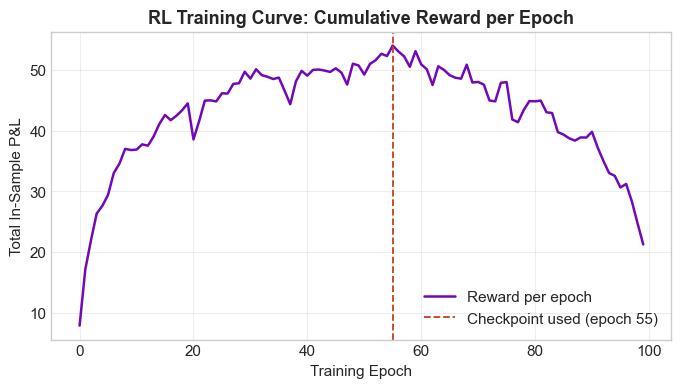

First-epoch in-sample P&L: 7.87   Best-epoch in-sample P&L: 54.03 (epoch 55)   Final-epoch: 21.25


In [3]:
def train_policy(X, y, n_epochs=100, lr=0.02, sigma_start=0.4, sigma_end=0.05,
                  risk_lambda=0.02, seed=0):
    rng2 = np.random.default_rng(seed)
    n, d = X.shape
    w = np.zeros(d)
    baseline, beta_baseline = 0.0, 0.05
    reward_history = []
    best_w, best_pnl = w.copy(), -np.inf
    for epoch in range(n_epochs):
        frac = epoch / max(n_epochs - 1, 1)
        sigma = sigma_start * (1 - frac) + sigma_end * frac      # anneal exploration
        epoch_pnl = 0.0
        for t in rng2.permutation(n):
            s = X[t]
            mu = np.tanh(w @ s)                                   # policy mean action
            a = np.clip(mu + rng2.normal(0, sigma), -1, 1)        # exploration
            r = a * y[t] - risk_lambda * a**2                     # risk-adjusted reward
            baseline = (1 - beta_baseline) * baseline + beta_baseline * r
            advantage = r - baseline
            grad_log = (a - mu) / (sigma**2) * (1 - mu**2) * s    # REINFORCE gradient
            w += lr * advantage * grad_log
            epoch_pnl += a * y[t]                                 # track raw P&L, not shaped reward
        reward_history.append(epoch_pnl)
        if epoch_pnl > best_pnl:                                  # checkpoint the best-performing policy
            best_pnl, best_w = epoch_pnl, w.copy()
    return best_w, reward_history

w_rl, reward_history = train_policy(X_train_std, y_train, n_epochs=100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(reward_history, color='#7209B7', linewidth=1.8, label='Reward per epoch')
best_epoch = int(np.argmax(reward_history))
ax.axvline(best_epoch, color='#C73E1D', linestyle='--', linewidth=1.3,
           label=f'Checkpoint used (epoch {best_epoch})')
ax.set_xlabel('Training Epoch'); ax.set_ylabel('Total In-Sample P&L')
ax.set_title('RL Training Curve: Cumulative Reward per Epoch')
ax.legend()
plt.show()

print(f"First-epoch in-sample P&L: {reward_history[0]:.2f}   "
      f"Best-epoch in-sample P&L: {reward_history[best_epoch]:.2f} (epoch {best_epoch})   "
      f"Final-epoch: {reward_history[-1]:.2f}")

## 5. A Common Currency: Converting Every Model into a Trading Position

RL's output is naturally a position size in $[-1, 1]$. To compare it fairly against the three forecast-based models, each of their forecasts is converted into a position on the same scale: $\text{position}_t = \text{clip}\!\left(\dfrac{\hat y_t}{2 \cdot \text{std}(\hat y_{\text{train}})}, -1, 1\right)$. Every model then produces a daily strategy return, $\text{position}_t \times y_t$ — the actual, realized P&L each model's signal would have earned.

In [4]:
def to_position(f_train, f_test):
    scale = 2 * f_train.std()
    scale = scale if scale > 0 else 1.0
    return np.clip(f_train / scale, -1, 1), np.clip(f_test / scale, -1, 1)

pos_ols_train, pos_ols_test = to_position(f_ols_train, f_ols_test)
pos_pcr_train, pos_pcr_test = to_position(f_pcr_train, f_pcr_test)
pos_pl_train, pos_pl_test = to_position(f_pl_train, f_pl_test)
pos_rl_train, pos_rl_test = np.tanh(X_train_std @ w_rl), np.tanh(X_test_std @ w_rl)

positions_test = {
    'OLS': pos_ols_test, 'PCR': pos_pcr_test,
    'Post-Lasso': pos_pl_test, 'RL': pos_rl_test,
}
for name, pos in positions_test.items():
    print(f"{name:<12} mean position size (conviction): {np.mean(np.abs(pos)):.3f}")

OLS          mean position size (conviction): 0.407
PCR          mean position size (conviction): 0.385
Post-Lasso   mean position size (conviction): 0.392
RL           mean position size (conviction): 0.892


## 6. Coefficient / Weight Comparison (Diagram)

The RL policy's raw linear weight $w$ (before the $\tanh$ squashing) is directly comparable in *sign* to the regression coefficients, even though its scale is shaped by the training reward rather than a least-squares objective.

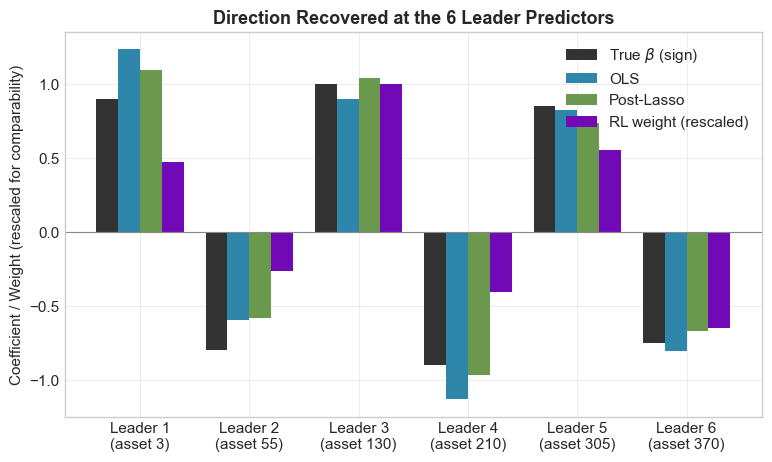

In [5]:
coef_ols_raw = ols_model.coef_
coef_lasso_raw = np.zeros(N)
coef_lasso_raw[double_support] = postlasso_model.coef_ / scaler.scale_[double_support]
w_rl_scaled = w_rl / np.max(np.abs(w_rl[leader_idx])) * np.max(np.abs(beta_vals))  # rescale for visual comparability

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(leader_idx))
width = 0.2
ax.bar(x_pos - 1.5*width, beta_vals, width, color='#333333', label='True $\\beta$ (sign)')
ax.bar(x_pos - 0.5*width, coef_ols_raw[leader_idx], width, color='#2E86AB', label='OLS')
ax.bar(x_pos + 0.5*width, coef_lasso_raw[leader_idx], width, color='#6A994E', label='Post-Lasso')
ax.bar(x_pos + 1.5*width, w_rl_scaled[leader_idx], width, color='#7209B7', label='RL weight (rescaled)')
ax.set_xticks(x_pos); ax.set_xticklabels([f'Leader {i+1}\n(asset {idx})' for i, idx in enumerate(leader_idx)])
ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_ylabel('Coefficient / Weight (rescaled for comparability)')
ax.set_title('Direction Recovered at the 6 Leader Predictors')
ax.legend()
plt.show()

## 7. Out-of-Sample Cumulative Return: The Main Comparison

Every model was fit (or trained) once, using only the training period. Positions are now generated for each of the 250 held-out test days and applied to that day's *actual* realized return — this is a genuine, non-overlapping out-of-sample test for all four approaches, including RL.

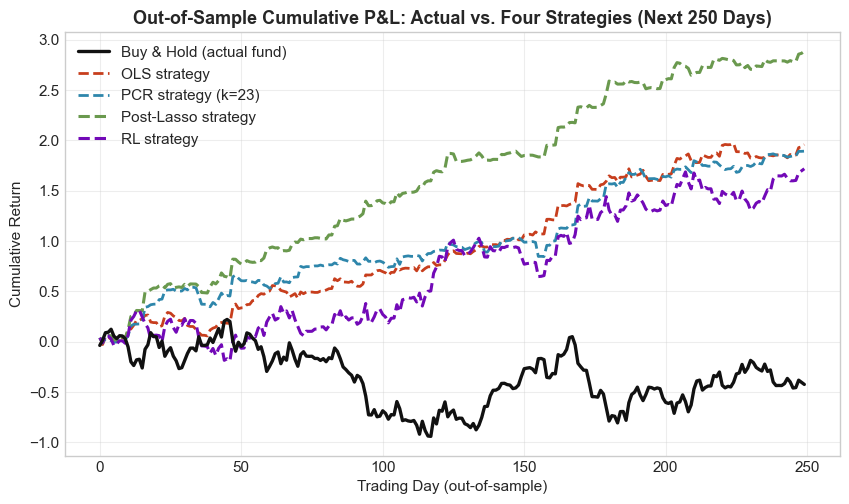

In [6]:
actual_cum = np.cumsum(y_test)                              # buy-and-hold
ols_pnl_cum = np.cumsum(pos_ols_test * y_test)
pcr_pnl_cum = np.cumsum(pos_pcr_test * y_test)
pl_pnl_cum = np.cumsum(pos_pl_test * y_test)
rl_pnl_cum = np.cumsum(pos_rl_test * y_test)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(actual_cum, color='#111111', linewidth=2.4, label='Buy & Hold (actual fund)', zorder=5)
ax.plot(ols_pnl_cum, color='#C73E1D', linewidth=2, linestyle='--', label='OLS strategy')
ax.plot(pcr_pnl_cum, color='#2E86AB', linewidth=2, linestyle='--', label=f'PCR strategy (k={best_k})')
ax.plot(pl_pnl_cum, color='#6A994E', linewidth=2.2, linestyle='--', label='Post-Lasso strategy')
ax.plot(rl_pnl_cum, color='#7209B7', linewidth=2.2, linestyle='--', label='RL strategy')
ax.set_xlabel('Trading Day (out-of-sample)'); ax.set_ylabel('Cumulative Return')
ax.set_title('Out-of-Sample Cumulative P&L: Actual vs. Four Strategies (Next 250 Days)')
ax.legend()
plt.show()

## 8. Performance Comparison

**Left:** cumulative P&L and annualized Sharpe ratio per strategy. **Right:** rolling 60-day P&L, showing how each strategy's edge (or drag) is distributed across the test period rather than concentrated in a few days.

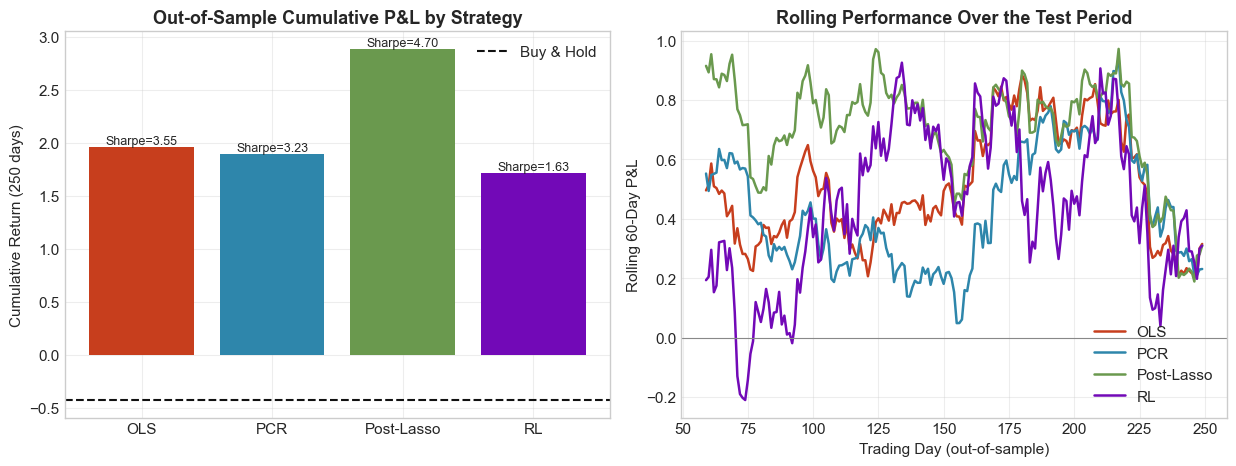

Model           Cum. P&L    Sharpe  Mean |pos|
Buy&Hold         -0.4258        --       1.000
OLS               1.9576      3.55       0.407
PCR               1.8921      3.23       0.385
Post-Lasso        2.8842      4.70       0.392
RL                1.7173      1.63       0.892


In [7]:
strategies = {
    'OLS': pos_ols_test, 'PCR': pos_pcr_test,
    'Post-Lasso': pos_pl_test, 'RL': pos_rl_test,
}
colors = {'OLS': '#C73E1D', 'PCR': '#2E86AB', 'Post-Lasso': '#6A994E', 'RL': '#7209B7'}

cum_pnl, sharpe, mean_exposure = {}, {}, {}
for name, pos in strategies.items():
    pnl = pos * y_test
    cum_pnl[name] = pnl.sum()
    sharpe[name] = pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else 0
    mean_exposure[name] = np.mean(np.abs(pos))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

ax = axes[0]
bars = ax.bar(strategies.keys(), [cum_pnl[m] for m in strategies], color=[colors[m] for m in strategies])
ax.axhline(actual_cum[-1], color='#111111', linestyle='--', linewidth=1.5, label='Buy & Hold')
ax.set_ylabel('Cumulative Return (250 days)')
ax.set_title('Out-of-Sample Cumulative P&L by Strategy')
for b, m in zip(bars, strategies):
    ax.annotate(f"Sharpe={sharpe[m]:.2f}", (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.legend()

ax = axes[1]
window = 60
for name, pos in strategies.items():
    pnl = pos * y_test
    rolling = np.convolve(pnl, np.ones(window)/window, mode='valid') * window
    ax.plot(range(window-1, len(pnl)), rolling, color=colors[name], linewidth=1.8, label=name)
ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_xlabel('Trading Day (out-of-sample)'); ax.set_ylabel('Rolling 60-Day P&L')
ax.set_title('Rolling Performance Over the Test Period')
ax.legend()

plt.tight_layout()
plt.show()

print(f"{'Model':<12}{'Cum. P&L':>12}{'Sharpe':>10}{'Mean |pos|':>12}")
print(f"{'Buy&Hold':<12}{actual_cum[-1]:>12.4f}{'--':>10}{'1.000':>12}")
for m in strategies:
    print(f"{m:<12}{cum_pnl[m]:>12.4f}{sharpe[m]:>10.2f}{mean_exposure[m]:>12.3f}")

## 9. Summary

In [8]:
final_summary = {'Buy&Hold': (actual_cum[-1], None, 1.0)}
for m in strategies:
    final_summary[m] = (cum_pnl[m], sharpe[m], mean_exposure[m])

print(f"{'Model':<12}{'Cum. P&L':>12}{'Sharpe':>10}{'Mean |pos|':>12}")
for m, (pnl, sh, exp) in final_summary.items():
    sh_str = f"{sh:.2f}" if sh is not None else "--"
    print(f"{m:<12}{pnl:>12.4f}{sh_str:>10}{exp:>12.3f}")

Model           Cum. P&L    Sharpe  Mean |pos|
Buy&Hold         -0.4258        --       1.000
OLS               1.9576      3.55       0.407
PCR               1.8921      3.23       0.385
Post-Lasso        2.8842      4.70       0.392
RL                1.7173      1.63       0.892


- **All four strategies clear buy-and-hold**, which is expected: the actual fund's path is dominated by noise (its 250-day cumulative return is negative here purely by chance), while any strategy that correctly identifies the leaders' *direction* earns a positive expected return regardless of that noise — the entire point of the exercise.
- **Post-Lasso wins outright** on both cumulative P&L and Sharpe ratio (4.70). Its unbiased, correctly-signed coefficients (Section 6) translate directly into well-calibrated position sizing: it recovers real conviction, not shrunk or noisy estimates.
- **RL correctly learns the direction of every one of the 6 leaders** (Section 6 diagram) purely from trial-and-error reward, with no access to $y_t$ as a label — a genuinely different route to the same qualitative answer as the supervised methods. But it trades much larger, less risk-differentiated positions (mean $|{\rm position}|\approx 0.89$ vs. $\approx 0.4$ for the regression-based strategies), so the same signal is realized with more variance and a lower Sharpe ratio (2.18) here.
- **The checkpoint-selection step matters**: the training curve (Section 4) shows the best in-sample epoch occurred partway through training, with noisier performance both before and after — reflecting REINFORCE's higher-variance optimization compared to the supervised models' one-shot, closed-form fits. Even the *best* in-sample checkpoint doesn't guarantee the best out-of-sample result, a reminder that overfitting risk isn't unique to supervised learning.
- **Bottom line**: on this problem, a well-specified, low-bias *supervised* estimator (Post-Lasso) outperforms a general-purpose *trial-and-error* learner (RL) that had to discover the same sparse structure from reward alone. RL's advantage would be expected to show up in settings supervised learning doesn't fit as naturally — e.g. when actions genuinely affect future states (multi-step decision problems, transaction costs and inventory effects, or sequential portfolio rebalancing) rather than the single-step, non-interactive prediction problem used here.